# 04｜CLIP 基準模型的跨資料集測試

載入 03 的最佳權重，在兩個訓練時完全未見過的資料集上推論：HiDF 與 Celeb-DF v2。

FF++ 內部測試只能說明模型學會了 Deepfakes 這一種偽造方法在這一批影片上的表現。跨資料集測試才能看出它學到的是通用的偽造痕跡，還是 FF++ 特有的資料特徵。

評估原則：

- 不使用外部資料集重新訓練、選擇模型或調整門檻，門檻固定為 0.5。
- 標籤只由所在的 `real`／`fake` 資料夾決定，檔名僅用於還原來源 ID。
- Celeb-DF 檔名的 `_f000030` 影格尾碼會移除，讓同一部影片的多張圖聚合到同一個 `video_id`。

## 1. 套件與環境

In [1]:
# %pip install -U open_clip_torch scikit-learn seaborn pandas pillow tqdm


In [2]:
from pathlib import Path
import json
import math
import os
import platform
import random
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

try:
    import open_clip
except ImportError as exc:
    raise ImportError(
        "尚未安裝 open_clip_torch。請先執行上一格的安裝指令，"
        "再重新啟動 Kernel。"
    ) from exc


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = [
            "Noto Sans CJK TC",
            "Noto Sans CJK SC",
            "WenQuanYi Zen Hei",
        ]

    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return candidates


FONT_CANDIDATES = setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("OpenCLIP：", getattr(open_clip, "__version__", "未知"))
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))


Python： 3.10.19
PyTorch： 2.5.1+cu121
OpenCLIP： 3.3.0
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070


## 2. 設定

`MAX_IMAGES_PER_DATASET` 必須為 `None`。若限制圖片數，Real 與 Fake 的比例會被破壞，得到的指標不能作為正式結果。

In [3]:
# 只需要修改這一格
HIDF_ROOT = Path(r"D:\資料\專題\PY\deepfake\研討會\dataset_HiDF5000\test")
CELEBDF_ROOT = Path(r"D:\資料\專題\PY\deepfake\研討會(二)\CelebDF_v2_balanced_test\test")

BEST_MODEL_PATH = Path(
    "./FFPP_CLIP_Baseline_Results/"
    "clip_vit_b16_ffpp_deepfakes/best_model.pth"
)
FFPP_TEST_METRICS_PATH = Path(
    "./FFPP_CLIP_Baseline_Results/"
    "clip_vit_b16_ffpp_deepfakes/test_metrics.json"
)
OUTPUT_ROOT = Path("./FFPP_CLIP_CrossDataset_Results")

DATASET_ROOTS = {
    "HiDF": HIDF_ROOT,
    "CelebDF_v2": CELEBDF_ROOT,
}

MODEL_NAME = "ViT-B-16-quickgelu"
PRETRAINED = "openai"
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0
SEED = 42

# 第一次可設 100 檢查流程；正式測試請設 None。
# 限制圖片時的指標不能作為正式結果。
MAX_IMAGES_PER_DATASET = None

# 安全開關：確認前面檢查皆正常後才改成 True。
RUN_EVALUATION = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"

print("HiDF：", HIDF_ROOT.resolve())
print("Celeb-DF：", CELEBDF_ROOT.resolve())
print("最佳模型：", BEST_MODEL_PATH.resolve())
print("輸出資料夾：", OUTPUT_ROOT.resolve())
print("裝置：", DEVICE)
print("執行安全開關：", RUN_EVALUATION)


HiDF： D:\資料\專題\PY\deepfake\研討會\dataset_HiDF5000\test
Celeb-DF： D:\資料\專題\PY\deepfake\研討會(二)\CelebDF_v2_balanced_test\test
最佳模型： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_CLIP_Baseline_Results\clip_vit_b16_ffpp_deepfakes\best_model.pth
輸出資料夾： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_CLIP_CrossDataset_Results
裝置： cuda
執行安全開關： True


## 3. 固定隨機種子

In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)
print("Random Seed：", SEED)


Random Seed： 42


## 4. 掃描資料與解析來源 ID

標籤只由資料夾決定，檔名不參與判定。這樣即使檔名格式與預期不符，最差的情況是 video-level 聚合失效，不會導致標籤錯置。

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
LABEL_MAPPING = {"real": 0, "fake": 1}


def find_class_name(path, root):
    relative_parts = [part.lower() for part in path.relative_to(root).parts]
    matches = [part for part in relative_parts[:-1] if part in LABEL_MAPPING]
    if not matches:
        raise ValueError(
            f"圖片不在 real／fake 資料夾下：{path}"
        )
    return matches[-1]


def parse_video_id(dataset_name, image_path, class_name):
    stem = image_path.stem

    if dataset_name == "CelebDF_v2":
        # real_00011_f000047 -> real_00011
        # fake_id0_id1_0001_f000030 -> fake_id0_id1_0001
        return re.sub(r"_f\d+$", "", stem, flags=re.IGNORECASE)

    if dataset_name == "HiDF":
        # Fake: c00046_c00110... -> c00046_c00110
        # Real: c00048... -> c00048
        if class_name == "fake":
            match = re.match(
                r"^(c\d+_c\d+)",
                stem,
                flags=re.IGNORECASE,
            )
        else:
            match = re.match(
                r"^(c\d+)",
                stem,
                flags=re.IGNORECASE,
            )
        if match:
            return match.group(1)

        return re.sub(
            r"_(?:f|frame)\d+$",
            "",
            stem,
            flags=re.IGNORECASE,
        )

    return re.sub(r"_f\d+$", "", stem, flags=re.IGNORECASE)


def scan_dataset(dataset_name, root):
    if not root.is_dir():
        raise FileNotFoundError(
            f"{dataset_name} 資料夾不存在：{root.resolve()}"
        )

    paths = sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    if not paths:
        raise FileNotFoundError(
            f"{dataset_name} 找不到支援的圖片：{root.resolve()}"
        )

    records = []
    invalid_paths = []
    for path in paths:
        try:
            class_name = find_class_name(path, root)
        except ValueError:
            invalid_paths.append(path)
            continue

        video_id = parse_video_id(dataset_name, path, class_name)
        records.append({
            "dataset": dataset_name,
            "path": str(path.resolve()),
            "file_name": path.name,
            "class_name": class_name,
            "label": LABEL_MAPPING[class_name],
            "video_id": video_id,
            "video_key": f"{class_name}::{video_id}",
        })

    if invalid_paths:
        print(
            f"{dataset_name}：略過 {len(invalid_paths):,} 張"
            "不在 real／fake 資料夾下的圖片。"
        )

    dataframe = pd.DataFrame(records)
    if dataframe.empty:
        raise ValueError(
            f"{dataset_name} 沒有可用圖片，請檢查 real／fake 資料夾。"
        )
    if dataframe["label"].nunique() < 2:
        raise ValueError(
            f"{dataset_name} 必須同時包含 Real 與 Fake。"
        )
    if dataframe["path"].duplicated().any():
        raise ValueError(f"{dataset_name} 發現重複圖片路徑。")

    if MAX_IMAGES_PER_DATASET is not None:
        sampled = []
        for _, group in dataframe.groupby("class_name"):
            count = min(
                math.ceil(MAX_IMAGES_PER_DATASET / 2),
                len(group),
            )
            sampled.append(group.sample(n=count, random_state=SEED))
        dataframe = (
            pd.concat(sampled, ignore_index=True)
            .head(MAX_IMAGES_PER_DATASET)
            .copy()
        )

    return dataframe.sort_values(
        ["class_name", "video_id", "file_name"]
    ).reset_index(drop=True)


dataset_frames = {
    name: scan_dataset(name, root)
    for name, root in DATASET_ROOTS.items()
}

summary_rows = []
for dataset_name, dataframe in dataset_frames.items():
    for class_name, group in dataframe.groupby("class_name"):
        summary_rows.append({
            "dataset": dataset_name,
            "class_name": class_name,
            "image_count": len(group),
            "video_count": group["video_key"].nunique(),
        })

dataset_summary_df = pd.DataFrame(summary_rows)
display(dataset_summary_df)

for dataset_name, dataframe in dataset_frames.items():
    print(f"\n{dataset_name} 檔名解析範例")
    display(
        dataframe[
            ["file_name", "class_name", "label", "video_id"]
        ].groupby("class_name", group_keys=False).head(3)
    )


,dataset,class_name,image_count,video_count
0,HiDF,fake,313,313
1,HiDF,real,313,313
2,CelebDF_v2,fake,534,178
3,CelebDF_v2,real,534,178



HiDF 檔名解析範例


,file_name,class_name,label,video_id
0,c00046_c00110.jpg,fake,1,c00046_c00110
1,c00128_c00121.jpg,fake,1,c00128_c00121
2,c00137_c00172.jpg,fake,1,c00137_c00172
313,c00048.jpg,real,0,c00048
314,c00057.jpg,real,0,c00057
315,c00096.jpg,real,0,c00096



CelebDF_v2 檔名解析範例


,file_name,class_name,label,video_id
0,fake_id0_id16_0003_f000052.png,fake,1,fake_id0_id16_0003
1,fake_id0_id16_0003_f000090.png,fake,1,fake_id0_id16_0003
2,fake_id0_id16_0003_f000128.png,fake,1,fake_id0_id16_0003
534,real_00011_f000047.png,real,0,real_00011
535,real_00011_f000081.png,real,0,real_00011
536,real_00011_f000115.png,real,0,real_00011


### ID 解析檢查

確認 Real／Fake 數量符合預期，且同一來源的多張影格解析到相同的 `video_id`。若解析失敗，video-level 結果會退化成 image-level。

## 5. 固定測試前處理

使用與 03 驗證／測試完全相同的 224×224 Bicubic Resize 與 CLIP 標準化，不加任何隨機增強。前處理若不一致，跨資料集的差異就無法歸因於資料本身。

In [6]:
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])


class ExternalDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        path = Path(row["path"])
        with Image.open(path) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(
                int(row["label"]),
                dtype=torch.long,
            ),
            "path": str(path),
            "file_name": str(row["file_name"]),
            "video_key": str(row["video_key"]),
            "video_id": str(row["video_id"]),
            "class_name": str(row["class_name"]),
            "dataset": str(row["dataset"]),
        }


dataloaders = {}
for dataset_name, dataframe in dataset_frames.items():
    dataset = ExternalDataset(dataframe, eval_transform)
    dataloaders[dataset_name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )
    print(
        f"{dataset_name}：{len(dataset):,} 張，"
        f"{len(dataloaders[dataset_name]):,} batches"
    )


HiDF：626 張，10 batches
CelebDF_v2：1,068 張，17 batches


## 6. 建立相同模型並載入最佳權重

重建與 03 相同的架構，並比對 checkpoint 內記錄的模型名稱與預訓練來源，確保載入的是同一個實驗的權重。

In [7]:
class FrozenCLIPClassifier(nn.Module):
    def __init__(self, model_name, pretrained, num_classes=2):
        super().__init__()
        self.backbone = open_clip.create_model(
            model_name,
            pretrained=pretrained,
        )
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        feature_dim = int(self.backbone.visual.output_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        self.classifier.train(mode)
        return self

    def forward(self, images):
        with torch.no_grad():
            features = self.backbone.encode_image(images)
            features = features.float()
            features = features / features.norm(
                dim=-1,
                keepdim=True,
            ).clamp_min(1e-6)
        return self.classifier(features)


if not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"找不到 best_model.pth：{BEST_MODEL_PATH.resolve()}"
    )

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)
if "model_state_dict" not in checkpoint:
    raise KeyError(
        "best_model.pth 中找不到 model_state_dict，"
        "請確認使用第三份 Notebook 產生的權重。"
    )

saved_config = checkpoint.get("config", {})
expected = {
    "model_name": MODEL_NAME,
    "pretrained": PRETRAINED,
    "image_size": IMAGE_SIZE,
}
mismatch = {
    key: (saved_config.get(key), value)
    for key, value in expected.items()
    if saved_config.get(key) is not None
    and saved_config.get(key) != value
}
if mismatch:
    raise ValueError(
        f"checkpoint 與本 Notebook 設定不一致：{mismatch}"
    )

model = FrozenCLIPClassifier(
    MODEL_NAME,
    PRETRAINED,
).to(DEVICE)
model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)
model.eval()

print("模型權重載入成功")
print("模型：", MODEL_NAME)
print("預訓練：", PRETRAINED)
print("訓練最佳 Epoch：", int(checkpoint.get("epoch", -1)) + 1)
print(
    "最佳驗證 Video AUC：",
    checkpoint.get("best_val_auc", "未記錄"),
)


模型權重載入成功
模型： ViT-B-16-quickgelu
預訓練： openai
訓練最佳 Epoch： 3
最佳驗證 Video AUC： 0.9825510204081633


## 7. 評估函式

In [8]:
def safe_auc(labels, probabilities):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    if np.unique(labels).size < 2:
        return float("nan")
    return float(roc_auc_score(labels, probabilities))


def binary_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    return {
        "sample_count": int(len(labels)),
        "real_count": int((labels == 0).sum()),
        "fake_count": int((labels == 1).sum()),
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": safe_auc(labels, probabilities),
        "threshold": float(threshold),
    }


def aggregate_video_predictions(image_df):
    label_counts = image_df.groupby("video_key")["label"].nunique()
    if (label_counts > 1).any():
        raise ValueError("同一 video_key 出現不同標籤。")

    return (
        image_df.groupby(
            [
                "dataset",
                "video_key",
                "video_id",
                "class_name",
            ],
            as_index=False,
        )
        .agg(
            label=("label", "first"),
            fake_probability=("fake_probability", "mean"),
            image_count=("fake_probability", "size"),
        )
    )


def evaluate_dataset(model, dataloader, dataset_name):
    records = []
    progress = tqdm(
        dataloader,
        desc=f"Evaluate {dataset_name}",
    )

    model.eval()
    with torch.no_grad():
        for batch in progress:
            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(images)

            probabilities = torch.softmax(logits, dim=1)[:, 1]
            for index in range(images.size(0)):
                records.append({
                    "dataset": batch["dataset"][index],
                    "path": batch["path"][index],
                    "file_name": batch["file_name"][index],
                    "video_key": batch["video_key"][index],
                    "video_id": batch["video_id"][index],
                    "class_name": batch["class_name"][index],
                    "label": int(batch["label"][index]),
                    "fake_probability": float(
                        probabilities[index].cpu()
                    ),
                })

    image_df = pd.DataFrame(records)
    image_df["prediction"] = (
        image_df["fake_probability"] >= 0.5
    ).astype(int)

    video_df = aggregate_video_predictions(image_df)
    video_df["prediction"] = (
        video_df["fake_probability"] >= 0.5
    ).astype(int)

    image_metrics = binary_metrics(
        image_df["label"],
        image_df["fake_probability"],
    )
    video_metrics = binary_metrics(
        video_df["label"],
        video_df["fake_probability"],
    )
    return image_df, video_df, image_metrics, video_metrics


## 8. 執行跨資料集推論

In [9]:
evaluation_results = {}
metric_rows = []

if not RUN_EVALUATION:
    print("目前 RUN_EVALUATION=False，尚未開始外部測試。")
    print("確認前面檢查正常後，改成 True 再執行本格。")
else:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

    for dataset_name, dataloader in dataloaders.items():
        (
            image_df,
            video_df,
            image_metrics,
            video_metrics,
        ) = evaluate_dataset(model, dataloader, dataset_name)

        dataset_dir = OUTPUT_ROOT / dataset_name
        dataset_dir.mkdir(parents=True, exist_ok=True)

        image_path = dataset_dir / "image_predictions.csv"
        video_path = dataset_dir / "video_predictions.csv"
        metrics_path = dataset_dir / "metrics.json"

        image_df.to_csv(
            image_path,
            index=False,
            encoding="utf-8-sig",
        )
        video_df.to_csv(
            video_path,
            index=False,
            encoding="utf-8-sig",
        )

        metrics_payload = {
            "dataset": dataset_name,
            "model_name": MODEL_NAME,
            "pretrained": PRETRAINED,
            "checkpoint": str(BEST_MODEL_PATH.resolve()),
            "threshold_source": "fixed FF++ model threshold 0.5",
            "image_level": image_metrics,
            "video_level": video_metrics,
        }
        with metrics_path.open("w", encoding="utf-8") as file:
            json.dump(
                metrics_payload,
                file,
                ensure_ascii=False,
                indent=2,
            )

        evaluation_results[dataset_name] = {
            "image_df": image_df,
            "video_df": video_df,
            "image_metrics": image_metrics,
            "video_metrics": video_metrics,
        }

        for level, metrics in [
            ("image", image_metrics),
            ("video", video_metrics),
        ]:
            metric_rows.append({
                "dataset": dataset_name,
                "level": level,
                **metrics,
            })

        print()
        print(dataset_name)
        print(
            json.dumps(
                metrics_payload,
                ensure_ascii=False,
                indent=2,
            )
        )
        print()
        print("Image-level Classification Report")
        print(
            classification_report(
                image_df["label"],
                image_df["prediction"],
                target_names=["Real", "Fake"],
                digits=4,
                zero_division=0,
            )
        )
        print("Video-level Classification Report")
        print(
            classification_report(
                video_df["label"],
                video_df["prediction"],
                target_names=["Real", "Fake"],
                digits=4,
                zero_division=0,
            )
        )

    external_metrics_df = pd.DataFrame(metric_rows)
    external_metrics_df.to_csv(
        OUTPUT_ROOT / "external_metrics_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display(external_metrics_df)


Evaluate HiDF:   0%|          | 0/10 [00:00<?, ?it/s]


HiDF
{
  "dataset": "HiDF",
  "model_name": "ViT-B-16-quickgelu",
  "pretrained": "openai",
  "checkpoint": "D:\\資料\\專題\\PY\\deepfake\\新版專題研究\\FFPP_CLIP_Baseline_Results\\clip_vit_b16_ffpp_deepfakes\\best_model.pth",
  "threshold_source": "fixed FF++ model threshold 0.5",
  "image_level": {
    "sample_count": 626,
    "real_count": 313,
    "fake_count": 313,
    "accuracy": 0.6501597444089456,
    "precision": 0.9196428571428571,
    "recall": 0.329073482428115,
    "f1": 0.48470588235294115,
    "auc": 0.8082607763680348,
    "threshold": 0.5
  },
  "video_level": {
    "sample_count": 626,
    "real_count": 313,
    "fake_count": 313,
    "accuracy": 0.6501597444089456,
    "precision": 0.9196428571428571,
    "recall": 0.329073482428115,
    "f1": 0.48470588235294115,
    "auc": 0.8082607763680348,
    "threshold": 0.5
  }
}

Image-level Classification Report
              precision    recall  f1-score   support

        Real     0.5914    0.9712    0.7352       313
        Fake 

Evaluate CelebDF_v2:   0%|          | 0/17 [00:00<?, ?it/s]


CelebDF_v2
{
  "dataset": "CelebDF_v2",
  "model_name": "ViT-B-16-quickgelu",
  "pretrained": "openai",
  "checkpoint": "D:\\資料\\專題\\PY\\deepfake\\新版專題研究\\FFPP_CLIP_Baseline_Results\\clip_vit_b16_ffpp_deepfakes\\best_model.pth",
  "threshold_source": "fixed FF++ model threshold 0.5",
  "image_level": {
    "sample_count": 1068,
    "real_count": 534,
    "fake_count": 534,
    "accuracy": 0.5664794007490637,
    "precision": 0.6839378238341969,
    "recall": 0.24719101123595505,
    "f1": 0.3631361760660248,
    "auc": 0.677010127789701,
    "threshold": 0.5
  },
  "video_level": {
    "sample_count": 356,
    "real_count": 178,
    "fake_count": 178,
    "accuracy": 0.5617977528089888,
    "precision": 0.6896551724137931,
    "recall": 0.2247191011235955,
    "f1": 0.3389830508474576,
    "auc": 0.695840171695493,
    "threshold": 0.5
  }
}

Image-level Classification Report
              precision    recall  f1-score   support

        Real     0.5406    0.8858    0.6714       534
 

,dataset,level,sample_count,real_count,fake_count,accuracy,precision,recall,f1,auc,threshold
0,HiDF,image,626,313,313,0.650160,0.919643,0.329073,0.484706,0.808261,0.5
1,HiDF,video,626,313,313,0.650160,0.919643,0.329073,0.484706,0.808261,0.5
2,CelebDF_v2,image,1068,534,534,0.566479,0.683938,0.247191,0.363136,0.677010,0.5
3,CelebDF_v2,video,356,178,178,0.561798,0.689655,0.224719,0.338983,0.695840,0.5


## 9. 混淆矩陣與 ROC Curve

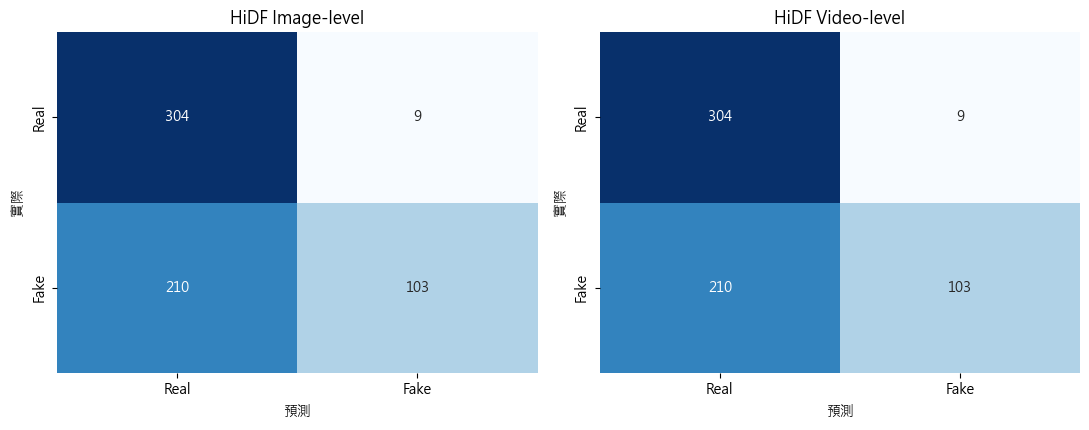

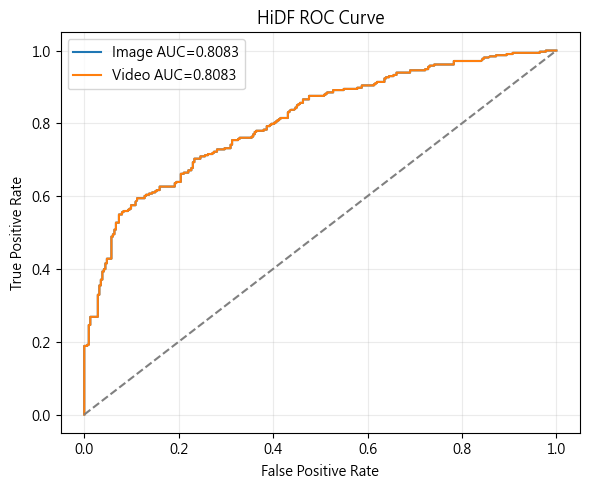

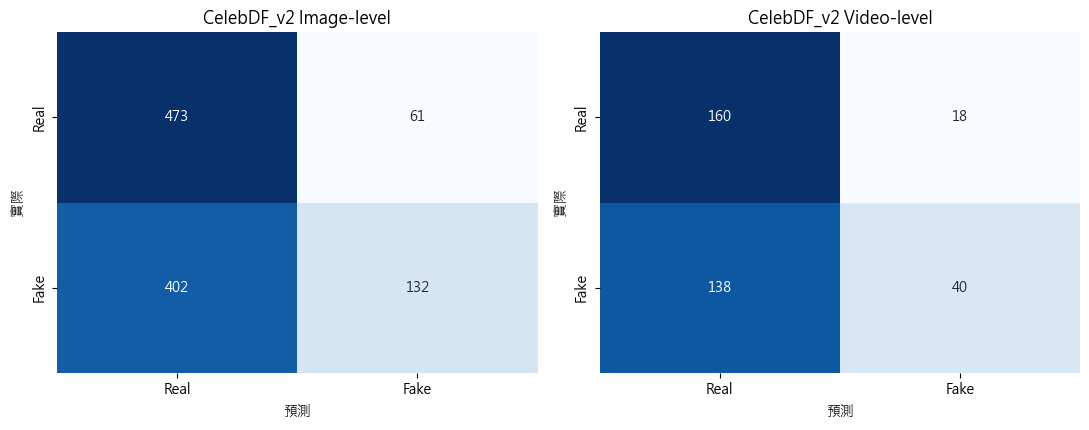

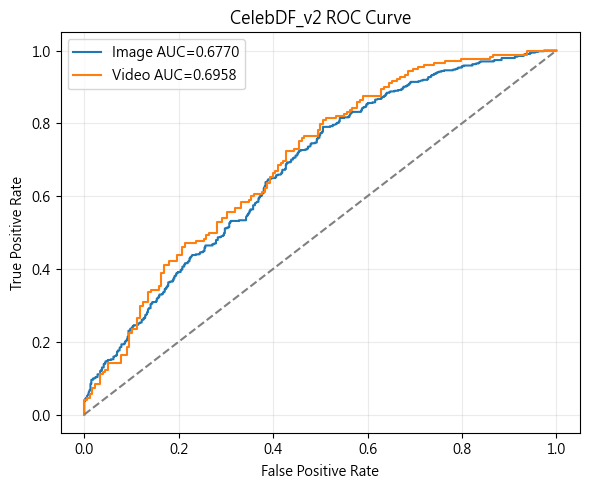

In [10]:
if not evaluation_results:
    print("尚未完成外部測試。")
else:
    for dataset_name, result in evaluation_results.items():
        dataset_dir = OUTPUT_ROOT / dataset_name
        image_df = result["image_df"]
        video_df = result["video_df"]
        image_metrics = result["image_metrics"]
        video_metrics = result["video_metrics"]

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
        for axis, dataframe, title in [
            (axes[0], image_df, "Image-level"),
            (axes[1], video_df, "Video-level"),
        ]:
            matrix = confusion_matrix(
                dataframe["label"],
                dataframe["prediction"],
                labels=[0, 1],
            )
            sns.heatmap(
                matrix,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"],
                ax=axis,
            )
            axis.set_title(f"{dataset_name} {title}")
            axis.set_xlabel("預測")
            axis.set_ylabel("實際")

        plt.tight_layout()
        plt.savefig(
            dataset_dir / "confusion_matrices.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()

        plt.figure(figsize=(6, 5))
        for dataframe, metrics, level_name in [
            (image_df, image_metrics, "Image"),
            (video_df, video_metrics, "Video"),
        ]:
            fpr, tpr, _ = roc_curve(
                dataframe["label"],
                dataframe["fake_probability"],
            )
            plt.plot(
                fpr,
                tpr,
                label=f"{level_name} AUC={metrics['auc']:.4f}",
            )

        plt.plot([0, 1], [0, 1], "--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{dataset_name} ROC Curve")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(
            dataset_dir / "roc_curve.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()


## 10. 三個資料集結果彙整

讀取 03 的 `test_metrics.json`，與兩個外部資料集併表，並計算相對 FF++ 的 AUC 下降量。跨資料集比較以 AUC 為主，因為 accuracy 受固定門檻影響，而門檻本身就是跨 domain 時最先失效的東西。

,dataset,level,accuracy,precision,recall,f1,auc,auc_drop_vs_ffpp
0,FFPP,image,0.896652,0.917332,0.871875,0.894026,0.967444,0.000000
1,FFPP,video,0.921429,0.940299,0.900000,0.919708,0.980459,0.000000
2,HiDF,image,0.650160,0.919643,0.329073,0.484706,0.808261,0.159184
3,HiDF,video,0.650160,0.919643,0.329073,0.484706,0.808261,0.172198
4,CelebDF_v2,image,0.566479,0.683938,0.247191,0.363136,0.677010,0.290434
5,CelebDF_v2,video,0.561798,0.689655,0.224719,0.338983,0.695840,0.284619


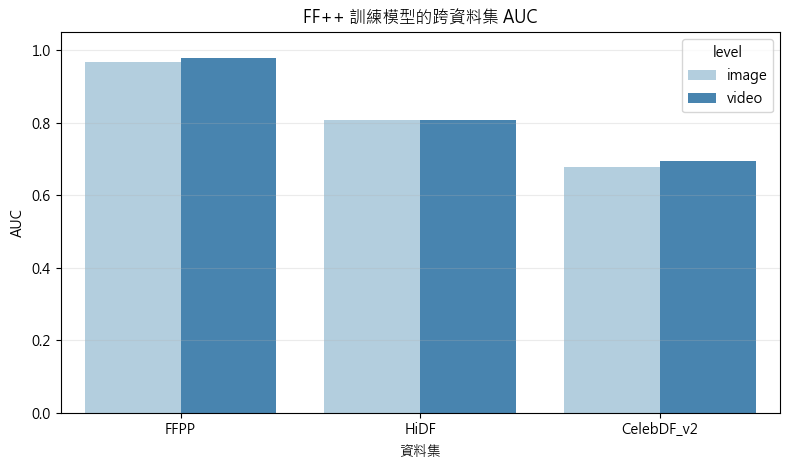

In [11]:
if not evaluation_results:
    print("尚未完成外部測試。")
else:
    comparison_rows = []

    if FFPP_TEST_METRICS_PATH.is_file():
        with FFPP_TEST_METRICS_PATH.open(
            "r",
            encoding="utf-8",
        ) as file:
            ffpp_metrics = json.load(file)

        for level, source_key in [
            ("image", "frame_level"),
            ("video", "video_level"),
        ]:
            metrics = ffpp_metrics[source_key]
            comparison_rows.append({
                "dataset": "FFPP",
                "level": level,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
            })
    else:
        print(
            "找不到 FF++ test_metrics.json，"
            "本次只整理 HiDF 與 Celeb-DF。"
        )

    for dataset_name, result in evaluation_results.items():
        for level, metrics in [
            ("image", result["image_metrics"]),
            ("video", result["video_metrics"]),
        ]:
            comparison_rows.append({
                "dataset": dataset_name,
                "level": level,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
            })

    comparison_df = pd.DataFrame(comparison_rows)
    ffpp_auc_map = (
        comparison_df[
            comparison_df["dataset"].eq("FFPP")
        ].set_index("level")["auc"].to_dict()
    )
    comparison_df["auc_drop_vs_ffpp"] = comparison_df.apply(
        lambda row: (
            ffpp_auc_map.get(row["level"], np.nan) - row["auc"]
            if row["dataset"] != "FFPP"
            else 0.0
        ),
        axis=1,
    )
    comparison_df.to_csv(
        OUTPUT_ROOT / "all_dataset_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display(comparison_df)

    plt.figure(figsize=(8, 4.8))
    chart_df = comparison_df.copy()
    sns.barplot(
        data=chart_df,
        x="dataset",
        y="auc",
        hue="level",
        palette="Blues",
    )
    plt.ylim(0, 1.05)
    plt.ylabel("AUC")
    plt.xlabel("資料集")
    plt.title("FF++ 訓練模型的跨資料集 AUC")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / "cross_dataset_auc.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## 11. 高信心誤判案例

僅用於錯誤分析，不據此回頭調整模型或門檻。

原本此處為 HiDF 與 Celeb-DF 的誤判樣本影像，因兩個資料集的授權條款限制影像再散布，已於公開版本移除。程式碼保留，可在本機重現。

In [12]:
if not evaluation_results:
    print("尚未完成外部測試。")
else:
    for dataset_name, result in evaluation_results.items():
        image_df = result["image_df"]
        errors_df = image_df[
            image_df["label"] != image_df["prediction"]
        ].copy()
        errors_df["error_confidence"] = np.where(
            errors_df["prediction"].eq(1),
            errors_df["fake_probability"],
            1.0 - errors_df["fake_probability"],
        )
        errors_df = errors_df.sort_values(
            "error_confidence",
            ascending=False,
        )
        errors_df.to_csv(
            OUTPUT_ROOT / dataset_name / "error_cases.csv",
            index=False,
            encoding="utf-8-sig",
        )

        sample_count = min(12, len(errors_df))
        print(
            f"{dataset_name} Image-level 誤判："
            f"{len(errors_df):,} 張"
        )
        if sample_count == 0:
            continue

        samples = errors_df.head(sample_count)
        columns = 4
        rows = math.ceil(sample_count / columns)
        fig, axes = plt.subplots(
            rows,
            columns,
            figsize=(12, 3 * rows),
        )
        axes = np.array(axes).reshape(-1)

        for axis, (_, row) in zip(
            axes,
            samples.iterrows(),
        ):
            with Image.open(row["path"]) as image:
                axis.imshow(image.convert("RGB"))
            axis.set_title(
                f"實際={row['class_name']}\n"
                f"P(Fake)={row['fake_probability']:.3f}"
            )
            axis.axis("off")

        for axis in axes[sample_count:]:
            axis.axis("off")

        plt.suptitle(f"{dataset_name} 高信心誤判案例")
        plt.tight_layout()
        plt.show()


HiDF Image-level 誤判：219 張


CelebDF_v2 Image-level 誤判：463 張


## 跨資料集結果

| 資料集 | 層級 | Accuracy | Recall | AUC | AUC 相對 FF++ 下降 |
|---|---|---|---|---|---|
| FF++ | image | 0.8967 | 0.8719 | 0.9674 | — |
| FF++ | video | 0.9214 | 0.9000 | 0.9805 | — |
| HiDF | image | 0.6502 | 0.3291 | 0.8083 | 0.159 |
| Celeb-DF v2 | image | 0.5665 | 0.2472 | 0.6770 | 0.290 |
| Celeb-DF v2 | video | 0.5618 | 0.2247 | 0.6958 | 0.285 |

兩個外部資料集的 AUC 分別下降 0.16 與 0.29。更值得注意的是 recall 的崩塌：HiDF 從 0.87 掉到 0.33，Celeb-DF 掉到 0.25，而 precision 仍維持在 0.68–0.92。

模型在跨 domain 時變得極度保守——它幾乎只在非常有把握時才判為 Fake，大量偽造樣本被判成 Real。這代表輸出機率的分布整體往 Real 方向偏移，固定門檻 0.5 已經不在合適的位置。這個現象在 09C 的手機資料測試上會以更極端的形式重現。